In [1]:
import os
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

# GPUs 1 und 3 sichtbar machen (deine echte GPUs 1 und 3)
os.environ["CUDA_VISIBLE_DEVICES"] = "1,3,5,6"

def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

model_name = "meta-llama/Meta-Llama-3-70B-Instruct"

df = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

batch_size = 8

print(f"📦 Lade Modell {model_name} ohne Quantisierung auf allen sichtbaren GPUs ...")

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",       # Automatische Verteilung auf alle sichtbaren GPUs
    torch_dtype=torch.float16,
    trust_remote_code=True
)
model.eval()

true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

results = []
confidences = []

print("🔍 Starte Batch-Verarbeitung ...")
for i in tqdm(range(0, len(statements), batch_size)):
    batch_texts = statements[i : i + batch_size]
    batch_prompts = [build_prompt(text) for text in batch_texts]

    inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    for j in range(len(batch_texts)):
        next_token_logits = logits[j, -1, :]
        probs = F.softmax(next_token_logits, dim=-1)

        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            results.append("True")
            confidences.append(prob_true)
        else:
            results.append("False")
            confidences.append(prob_false)

suffix = model_name.split("/")[-1]
df[f"label_{suffix}"] = results
df[f"confidence_{suffix}"] = confidences

print("\n✅ Verarbeitung abgeschlossen.")
df


📦 Lade Modell meta-llama/Meta-Llama-3-70B-Instruct ohne Quantisierung auf allen sichtbaren GPUs ...


2025-07-02 14:14:18.229244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751458458.246872   23931 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751458458.251780   23931 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 14:14:18.269958: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

🔍 Starte Batch-Verarbeitung ...


100%|██████████| 159/159 [15:48<00:00,  5.96s/it]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_Meta-Llama-3-70B-Instruct,confidence_Meta-Llama-3-70B-Instruct
0,true,Building a wall on the U.S . Mexico border wil...,immigration,False,0.000008
1,false,Wisconsin is on pace to double the number of l...,jobs,False,0.000008
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.000008
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.000008
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,0.000008
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,False,0.000006
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.000002
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.000066
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False,0.000003


In [ ]:
def clean_label(val):
    val = str(val).strip().lower().replace(".", "")
    if val == "true":
        return "True"
    elif val == "false":
        return "False"
    else:
        return "True"

df["label_Llama-3.1-8B-Instruct"] = df["label_Llama-3.1-8B-Instruct"].apply(clean_label)

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Meta-Llama-3-70B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[453 261]
 [366 187]]

Accuracy:  0.505130228887135
Precision: 0.5531135531135531  (bezogen auf 'True')
Recall:    0.634453781512605  (bezogen auf 'True')
F1 Score:  0.5909980430528375  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.42      0.34      0.37       553
       False       0.55      0.63      0.59       714

    accuracy                           0.51      1267
   macro avg       0.49      0.49      0.48      1267
weighted avg       0.49      0.51      0.50      1267



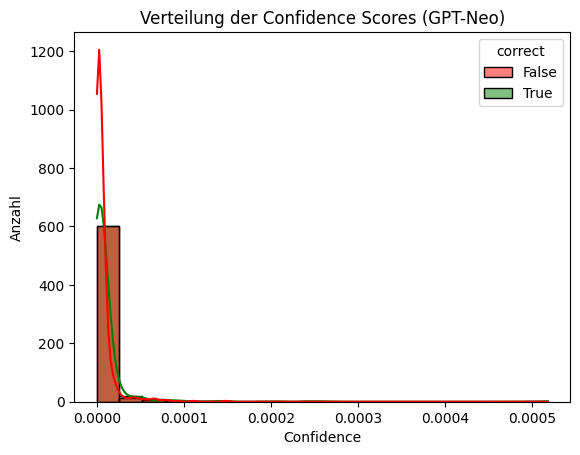

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Meta-Llama-3-70B-Instruct"]

sns.histplot(data=df, x="confidence_Meta-Llama-3-70B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# subjects

In [ ]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Liste der Modelle mit ihrer Architektur
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    #"google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"Datasets/LIAR/preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse Container
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip())

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for text in statements:  # Roberta verwendet nur das statement
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse im DataFrame speichern
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Export
#df.to_csv("statements_with_predictions_T5.csv", index=False)
#print("Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df

c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.89s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Set

,label,statement,subjects,label_Llama-3.1-8B-Instruct
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True
1,false,Wisconsin is on pace to double the number of l...,jobs,False
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False.
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",True
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True
...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[307 272]
 [165 280]]
Accuracy: 0.4632991318074191
Precision: 0.1447087632031442
Recall: 0.11703763783994611
F1-Score: 0.12806173838065515
              precision    recall  f1-score   support

        True       0.65      0.43      0.52       714
       False       0.51      0.51      0.51       553

   micro avg       0.57      0.46      0.51      1267
   macro avg       0.58      0.47      0.51      1267
weighted avg       0.59      0.46      0.51      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# extern subject classification

In [ ]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

# Zero-Shot-Classifier laden
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Labels definieren
labels = [
    "health", "economy", "politics", "education", "science",
    "technology", "environment", "sports", "law", "crime",
    "military", "immigration", "transportation", "energy", "culture",
    "foreign policy", "social issues", "business", "agriculture",
    "housing", "taxes", "welfare", "religion"
]

# CSV laden
df = pd.read_csv("Datasets/LIAR/preprocessed_test_cleaned.csv", sep="\t")

# Für jede Zeile das Top-Label bestimmen
domains = []
for text in tqdm(df["statement"], desc="Classifying domains"):
    result = classifier(text, candidate_labels=labels)
    domains.append(result["labels"][0])  # Top-Label

df["domain"] = domains

# Ergebnis speichern
df.to_csv("preprocessed_test_with_domain.csv", index=False)

Device set to use cuda:0
Classifying domains: 100%|██████████| 1267/1267 [13:16<00:00,  1.59it/s]


In [ ]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"The statement was categorized by a human as: {subjects}.\n"
        f"Respond strictly with one word: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"

    )

# Liste der Modelle mit ihrer Architektur
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    #"google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["domain"].tolist()

# Ergebnisse Container
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip())

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for text in statements:  # Roberta verwendet nur das statement
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse im DataFrame speichern
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Export
#df.to_csv("statements_with_predictions_T5.csv", index=False)
#print("Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df

c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards: 100%|██████████| 4/4 [00:22<00:00,  5.55s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Set

,label,statement,subjects,domain,label_Llama-3.1-8B-Instruct
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,True
1,false,Wisconsin is on pace to double the number of l...,jobs,business,True
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,False
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,True
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,True
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,True
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,True
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,True
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,True


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[516  62]
 [372 104]]
Accuracy: 0.489344909234412
Precision: 0.3018967762943666
Recall: 0.22768854377193914
F1-Score: 0.23337135951409835
              precision    recall  f1-score   support

        True       0.58      0.72      0.64       714
       False       0.63      0.19      0.29       553

   micro avg       0.59      0.49      0.53      1267
   macro avg       0.60      0.46      0.47      1267
weighted avg       0.60      0.49      0.49      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# tone classification

In [ ]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Domain (falls relevant)
def build_prompt(statement, subjects):
    return (
        f"Classify the tone of the following statement. "
        f"Choose one of: neutral, subjective, ironic, or emotional.\n\n"
        f"Statement: \"{statement}\"\n"
        f"Tone:"
    )

# Modelle und Typen
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    # Weitere Modelle bei Bedarf hier einfügen
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["domain"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}

# Durchlauf für jedes Modell
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=10)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            # Entfernt Prompt + nur Neutralen Text behalten
            result = decoded.split("Neutral:")[-1].strip()
            results[model_name].append(result)
            
# Ergebnisse in DataFrame einfügen
for model_name in results:
    df[f"tone"] = results[model_name]

# Export
output_path = "statements_tone.csv"
df.to_csv(output_path, index=False)
print(f"✅ Fertig – Ergebnisse gespeichert in '{output_path}'")


c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.87s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Set

✅ Fertig – Ergebnisse gespeichert in 'statements_tone.csv'


In [ ]:
df= pd.read_csv("statements_tone.csv")


import re

def extract_tone(text):
    if pd.isna(text):
        return ""
    # Suche nach dem ersten Vorkommen des Ton-Worts nach 'Tone:'
    match = re.search(r'Tone:\s*([a-zA-Z-]+)', str(text))
    if match:
        return match.group(1).strip().lower()
    # Falls das nicht klappt, suche allgemein im Text
    match2 = re.search(r'\b(neutral|subjective|ironic|emotional)\b', str(text).lower())
    return match2.group(1) if match2 else ""

df["tone"] = df["tone"].apply(extract_tone)

df.to_csv("statements_tone_cleaned.csv", index=False)

In [ ]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt nur mit Statement und Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modell(e)
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    # Weitere Modelle optional aktivieren
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse vorbereiten
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto"
        )

        for statement, tone in zip(statements, tones):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto"
        )

        for statement, tone in zip(statements, tones):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip().split()[0])

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for statement in statements:
            inputs = tokenizer(statement, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse anhängen
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Speichern
#df.to_csv("statements_with_predictions.csv", index=False)
#print("✅ Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df


c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔄 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  3.00s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Set

,label,statement,subjects,domain,tone,label_Llama-3.1-8B-Instruct
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,neutral,False
1,false,Wisconsin is on pace to double the number of l...,jobs,business,subjective,True
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,subjective,False
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,subjective,True
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,neutral,True
...,...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,neutral,True
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,neutral,True
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,neutral,True
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,neutral,True


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[602  97]
 [380 164]]
Accuracy: 0.6045777426992897
Precision: 0.3103467784098446
Recall: 0.2849253625500833
F1-Score: 0.2782135158314404
              precision    recall  f1-score   support

        True       0.61      0.84      0.71       714
       False       0.63      0.30      0.40       553

   micro avg       0.62      0.60      0.61      1267
   macro avg       0.62      0.57      0.56      1267
weighted avg       0.62      0.60      0.58      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
